In [8]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator

warnings.filterwarnings("ignore")
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,
    'axes.titlesize': 7,
    'axes.labelsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'figure.titlesize': 7,
    'figure.dpi': 200,
    'axes.linewidth': 0.7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

In [9]:
# Load and annotate data
raw_data = pd.read_csv("data/human.gencodeV44.pc_canonical.mut_info.tsv", sep="\t")
histone_anno = pd.read_csv("data/Human.gencodev44.histone.tsv", sep="\t")

# Filtering for relevant genes and regions
raw_data = raw_data[
    (raw_data["region"] == "CDS")
    & (raw_data["gene type"] == "protein_coding")
    & (raw_data["bigwig name"].isin(["allsite_snv", "allsite_indel_1_3bp"]))
]

# Annotate gene type
raw_data["gene_type"] = "Other genes"
raw_data.loc[
    raw_data["gene name"].isin(
        histone_anno[histone_anno["Type"] == "RDH"]["Genename"].to_list()
    ),
    "gene_type",
] = "RDH"
raw_data.loc[
    raw_data["gene name"].isin(
        histone_anno[histone_anno["Type"] == "RIH"]["Genename"].to_list()
    ),
    "gene_type",
] = "RIH"

raw_data["RDH family"] = "Other genes"
is_rdh = raw_data["gene_type"] == "RDH"

for fam in ["H1", "H2A", "H2B", "H3", "H4"]:
    raw_data.loc[raw_data["gene name"].str.startswith(fam) & is_rdh, "RDH family"] = fam

# Filtering and labeling RIH
data_filtered = raw_data[raw_data["non-nan length"] > 50].copy()
data_filtered.loc[data_filtered["gene_type"] == "RIH", "RDH family"] = "RIH"

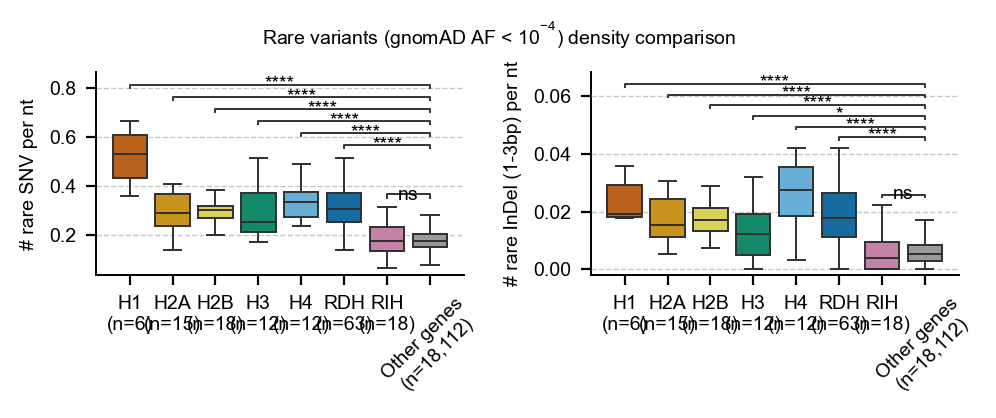

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(5, 2.1))

ORDER = ["H1", "H2A", "H2B", "H3", "H4", "RDH", "RIH", "Other genes"]
COLOR_MAP = {
    "H1": "#D55E00",         # vermillion
    "H2A": "#E69F00",        # orange
    "H2B": "#F0E442",        # yellow
    "H3": "#009E73",         # bluish green
    "H4": "#56B4E9",         # sky blue
    "RDH": "#0072B2",      # blue (aggregate)
    "RIH": "#CC79A7",      # reddish purple
    "Other genes": "#999999" # grey
}
PALETTE = [COLOR_MAP[k] for k in ORDER]

def add_rdhgs_group(df: pd.DataFrame) -> pd.DataFrame:
    # Add aggregate RDH group
    rdhg_members = ["H1", "H2A", "H2B", "H3", "H4"]
    rdhgs_df = df[df["RDH family"].isin(rdhg_members)].copy()
    rdhgs_df["RDH family"] = "RDH"
    out = pd.concat([df.copy(), rdhgs_df], ignore_index=True)
    out["RDH family"] = pd.Categorical(out["RDH family"], categories=ORDER, ordered=True)
    return out

def set_xtick_with_n(ax, df, xcol="RDH family", order=None):
    # Set x-tick labels with counts
    if order is None:
        order = list(pd.unique(df[xcol]))

    counts = df.groupby(xcol).size().to_dict()
    labels = []
    for cat in order:
        n = int(counts.get(cat, 0))
        labels.append(f'{cat}\n(n={n:,})')

    ax.set_xticklabels(labels)

# Function to plot each panel
def plot_panel(ax, bigwig_name, ylabel, text_offset=-3):

    # Subset data and add RDH group
    sub_df = data_filtered[
        data_filtered["bigwig name"] == bigwig_name
    ].copy()
    sub_df = add_rdhgs_group(sub_df)

    # Create boxplot
    sns.boxplot(
        data=sub_df,
        ax=ax,
        x="RDH family",
        y="mean value",
        order=ORDER,
        palette=PALETTE,
        linewidth=0.7,
        showfliers=False,
        zorder=5,
    )
    # Set x-tick labels with counts
    set_xtick_with_n(
        ax,
        sub_df,
        xcol="RDH family",
        order=ORDER,
    )
    # Add statistical annotations
    present = set(sub_df["RDH family"].dropna().unique().tolist())
    pairs = [
        (g, "Other genes")
        for g in ORDER
        if g != "Other genes" and (g in present) and ("Other genes" in present)
    ]
    annotator = Annotator(
        ax,
        pairs,
        data=sub_df,
        x="RDH family",
        y="mean value",
        order=ORDER,
    )
    annotator.configure(
        test="Mann-Whitney",
        text_format="star",
        loc="inside",
        verbose=0,
        line_width=0.7,
        text_offset=text_offset,
        comparisons_correction="BH",
    )
    annotator.apply_and_annotate()
    # Finalize aesthetics
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.set_title("")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7, zorder=-1)

# Plot panels
plot_panel(axes[0], "allsite_snv", "# rare SNV per nt", text_offset=-3.3)
plot_panel(axes[1], "allsite_indel_1_3bp", "# rare InDel (1-3bp) per nt", text_offset=-3)

# Customize x-axis labels and spines
for ax in axes:
    ax.tick_params(axis='x', labelsize=7)

    labels = ax.get_xticklabels()
    for i, lab in enumerate(labels):
        if i == len(labels) - 1:
            lab.set_rotation(45)
            lab.set_ha("center")
        else:
            lab.set_rotation(0)

    for spine in ax.spines.values():
        spine.set_zorder(15)

fig.suptitle(r"Rare variants (gnomAD AF < $10^{-4}$) density comparison", y=0.95)
plt.tight_layout()